# An agent that draws: jsonplot + Pydantic AI

The contract is a pydantic model. Pydantic AI is an agent framework built on
pydantic. So there is no glue to write here — the framework's `output_type` *is*
the contract, and its retry mechanism *is* the repair loop.

What this notebook builds:

| Piece | Comes from |
|---|---|
| what the model is told it may produce | `jp.contract(df)` — generated from the code that executes it |
| the shape of the answer | `output_type=NativeOutput(Spec)`, the same model the renderer consumes |
| the check pydantic cannot do (do these columns exist?) | an `@output_validator` calling `jp.validate(spec, df)` |
| the repair loop | `ModelRetry` carrying the structured errors back |
| the figure | `jp.plot(spec, df)` |

It runs against a local model through Ollama, so nothing leaves the machine:

```bash
ollama serve &
ollama pull qwen2.5:7b-instruct
uv sync            # pydantic-ai is in the dev group
```

In [1]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pydantic_ai import Agent, ModelRetry, RunContext
from pydantic_ai.models.ollama import OllamaModel
from pydantic_ai.output import NativeOutput
from pydantic_ai.providers.ollama import OllamaProvider
from pydantic_ai.settings import ModelSettings

# so `sample_data` resolves whether this runs from examples/ or the repo root
HERE = Path.cwd()
sys.path.insert(0, str(HERE if (HERE / "sample_data.py").exists() else HERE / "examples"))

import jsonplot as jp
from jsonplot import agent as jp_agent
from jsonplot.spec.models import Spec
from sample_data import sales

%matplotlib inline

df = sales()
df.head()

,date,region,channel,units,price,satisfaction,revenue
0,2024-01-02,South,Store,30,31.53,4.0,945.90
1,2024-01-02,North,Store,17,38.07,5.0,647.19
2,2024-01-02,North,Online,34,66.80,5.0,2271.20
3,2024-01-03,East,Online,4,117.25,4.1,469.00
4,2024-01-03,Central,Store,14,46.66,4.5,653.24


## 1. What the model is allowed to produce

`jp.contract(df)` writes the contract out: the chart types and the channels each
one takes, the vocabulary, the rules the validator enforces, and the columns of
*this* DataFrame. Every line of it is read from the definitions the framework
actually executes — the capability table, the `Literal`s in the models, the
installed renderers — so it cannot describe a version of jsonplot that no longer
exists.

Two sections are left out on purpose:

- **`flat`** — the flat dialect (`x_axis`, `agg`, …) is for hand-written
  contracts. Here the answer is parsed straight into `Spec`, which is canonical
  and rejects unknown keys, so advertising the shortcuts would only invite
  errors.
- **`output`** — the notebook decides the format, not the model.

In [2]:
SECTIONS = ("overview", "shape", "types", "channels", "data", "style", "rules", "example")
CONTRACT = jp.contract(df, include=SECTIONS)

print(f"{len(CONTRACT):,} characters\n")
print(CONTRACT[:1200], "\n[...]")

8,251 characters

# The visualization contract

## The data

```
DataFrame: 2000 rows, 7 columns

  - date: datetime64[us] (temporal); 533 distinct values; range 2024-01-02 00:00:00 – 2025-06-30 00:00:00
  - region: str (nominal); 4 distinct values; e.g. 'South', 'North', 'East'
  - channel: str (nominal); 2 distinct values; e.g. 'Store', 'Online'
  - units: int64 (quantitative); 39 distinct values; range 1 – 39
  - price: float64 (quantitative); 1771 distinct values; range 4.37 – 199.49
  - satisfaction: float64 (quantitative); 32 distinct values; range 1.8 – 5.0
  - revenue: float64 (quantitative); 1971 distinct values; range 8.41 – 6559.56
```

Use these column names exactly as written, capitalization included.

## What you are producing

A **contract**: a JSON object that declares which column of an already-loaded
DataFrame goes in which visual channel. You are not writing plotting code, and
no code you write will be executed. The framework draws the figure.

Answer with the JSON o

## 2. The agent

`output_type=NativeOutput(Spec)` hands Ollama the contract's JSON Schema as a
grammar constraint, so what comes back is schema-valid at generation time and
pydantic parses it into the very object `jp.plot` consumes. No string wrangling,
no `json.loads` on a fenced block, no "reply with only JSON" pleading.

The DataFrame travels as `deps` rather than a global: the validator below needs
it, and this way the same agent serves whatever data a request carries.

In [3]:
model = OllamaModel(
    "qwen2.5:7b-instruct",
    provider=OllamaProvider(base_url="http://localhost:11434/v1"),
)


@dataclass
class Deps:
    """What a run is about: the data the contract will be checked against."""
    df: pd.DataFrame


chart_agent = Agent(
    model,
    deps_type=Deps,
    output_type=NativeOutput(Spec),
    instructions=CONTRACT,
    model_settings=ModelSettings(temperature=0),
    retries=2,          # how many repair rounds the loop below is granted
)

## 3. The check pydantic cannot do

`Spec` guarantees the contract is *well formed*: a real `viz_type`, an
`aggregate` from the allowed set, no invented keys. It cannot guarantee the
contract is *executable*, because it has never seen the data — `region` and
`regionn` are both strings.

That is what `jp.validate(spec, df)` is for, and an `output_validator` is where
it belongs: raising `ModelRetry` sends the errors back to the model as a new
turn, and Pydantic AI runs the loop up to `retries`. The errors are already
JSON objects with `code`, `path`, `hint` and `did_you_mean` — written to be read
by a model, not by a human staring at a traceback.

In [4]:
@chart_agent.output_validator
def must_run_on_this_data(ctx: RunContext[Deps], spec: Spec) -> Spec:
    errors = jp.validate(spec, ctx.deps.df)
    if errors:
        raise ModelRetry(jp_agent.errors_as_json(errors))
    return spec

## 4. Ask, and draw

`jp.plot` is the only thing in this notebook that touches matplotlib. The model
never emitted a line of code, so there is nothing to execute and nothing to
sandbox.

Revenue per month over time, one line per region.
  0 repair round(s), 2,645 tokens
  {"viz_type": "line", "encoding": {"x": {"field": "date", "type": "temporal", "time_unit": "month"}, "y": {"field": "revenue", "type": "quantitative", "aggregate": "sum"}, "color": {"field": "region", "type": "nominal"}}, "style": {"title": "Revenue per month by region"}}


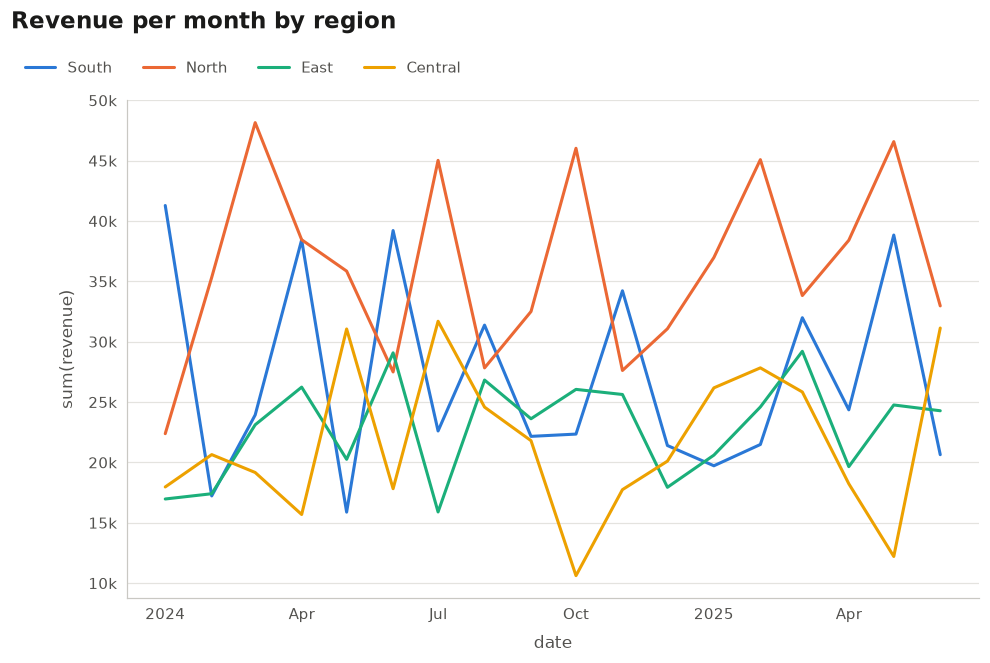

In [5]:
async def ask(question: str, data: pd.DataFrame | None = None):
    """Question in, (contract, figure) out. Prints what the loop cost.

    `await agent.run(...)` rather than `run_sync`: a notebook kernel already has
    an event loop running, and `run_sync` would try to start a second one.
    """
    frame = df if data is None else data
    result = await chart_agent.run(question, deps=Deps(frame))
    retries = [p for m in result.all_messages() for p in m.parts
               if type(p).__name__ == "RetryPromptPart"]
    print(f"{question}\n  {len(retries)} repair round(s), "
          f"{result.usage.total_tokens:,} tokens")
    print("  " + json.dumps(result.output.model_dump(exclude_defaults=True)))
    figure = jp.plot(result.output, frame)
    plt.close(figure)      # returned, not auto-displayed: shown once, where asked
    return result, figure


result, fig = await ask("Revenue per month over time, one line per region.")
fig

## 5. The loop, when it is needed

`profit` is not a column in this DataFrame. The model invents something, the
validator rejects it with a located `COLUMN_NOT_FOUND`, and the second attempt
uses a column that exists. Nothing here was written for this case — it is the
same validator, doing the only thing it does.

Total profit by region.
  1 repair round(s), 5,390 tokens
  {"viz_type": "bar", "encoding": {"x": {"field": "region", "type": "nominal"}, "y": {"field": "revenue", "type": "quantitative", "aggregate": "sum"}}, "style": {"title": "Total profit by region"}}

--- what went back to the model ---
[
  {
    "code": "COLUMN_NOT_FOUND",
    "path": "encoding.y.field",
    "message": "column 'revenue - price * units' is not in the DataFrame",
    "hint": "use one of the columns returned by describe_dataframe(df)"
  }
]


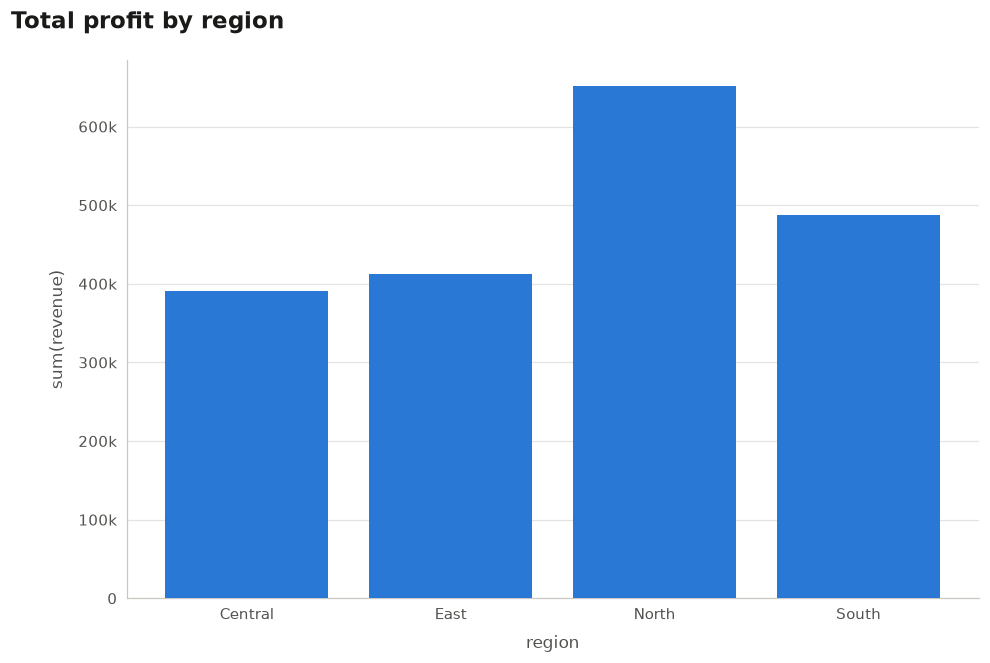

In [6]:
result, fig = await ask("Total profit by region.")

for message in result.all_messages():
    for part in message.parts:
        if type(part).__name__ == "RetryPromptPart":
            print("\n--- what went back to the model ---")
            print(part.content if isinstance(part.content, str)
                  else json.dumps(part.content, indent=2, default=str))

fig

## 6. A few more

Aggregation, top-N, filtering, distributions — the same agent, no per-question
code.

In [7]:
questions = [
    "The three regions with the most revenue, biggest bar first.",
    "Average satisfaction by channel, only in the North region.",
    "How is satisfaction spread across regions?",
    "Is there a relationship between price and units sold?",
]

figures = []
for question in questions:
    _, figure = await ask(question)
    figures.append(figure)
    print()

The three regions with the most revenue, biggest bar first.
  0 repair round(s), 2,633 tokens
  {"viz_type": "bar", "data": {"sort": {"by": "y", "order": "desc"}, "limit": 3}, "encoding": {"x": {"field": "region", "type": "nominal"}, "y": {"field": "revenue", "type": "quantitative", "aggregate": "sum"}}}



Average satisfaction by channel, only in the North region.
  0 repair round(s), 2,657 tokens
  {"viz_type": "bar", "data": {"filters": [{"field": "region", "op": "eq", "value": "North"}]}, "encoding": {"x": {"field": "channel", "type": "nominal"}, "y": {"field": "satisfaction", "type": "quantitative", "aggregate": "mean"}}, "style": {"title": "Average satisfaction by channel in the North region"}}



How is satisfaction spread across regions?
  0 repair round(s), 2,604 tokens
  {"viz_type": "box", "encoding": {"x": {"field": "region", "type": "nominal"}, "y": {"field": "satisfaction", "type": "quantitative"}}, "style": {"title": "Satisfaction spread across regions"}}



Is there a relationship between price and units sold?
  0 repair round(s), 2,607 tokens
  {"viz_type": "scatter", "encoding": {"x": {"field": "price", "type": "quantitative"}, "y": {"field": "units", "type": "quantitative"}}, "style": {"title": "Relationship between Price and Units Sold"}}



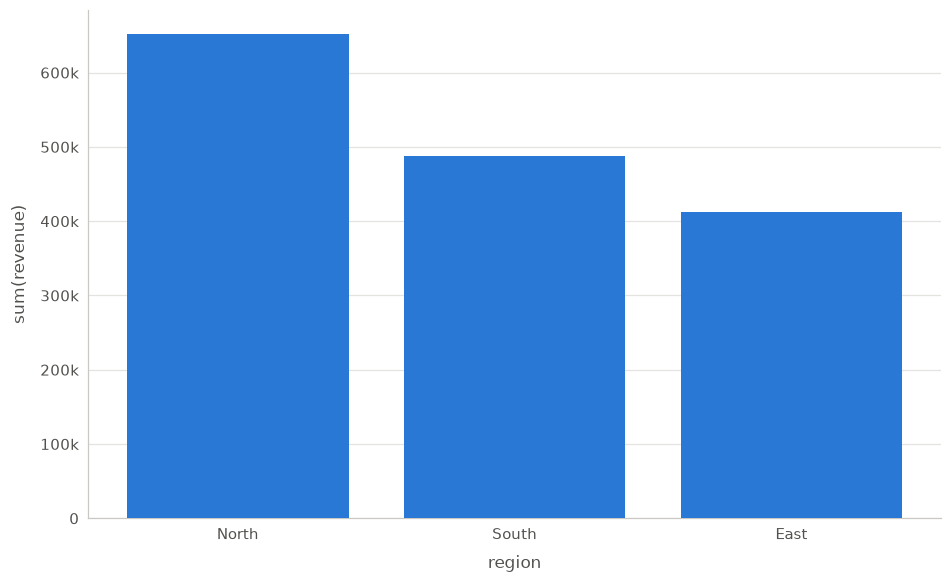

In [8]:
figures[0]

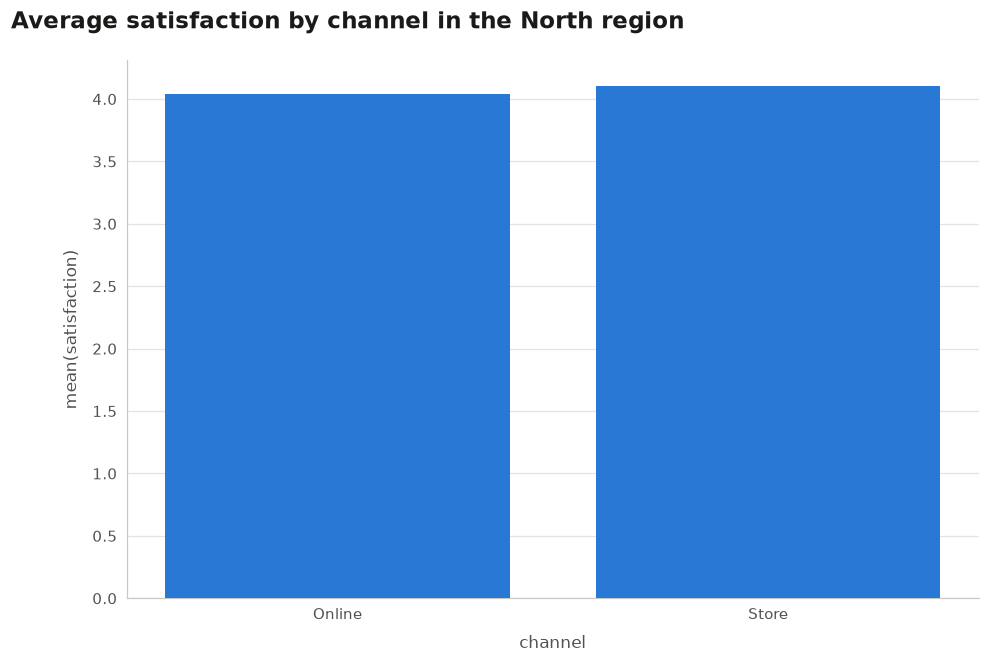

In [9]:
figures[1]

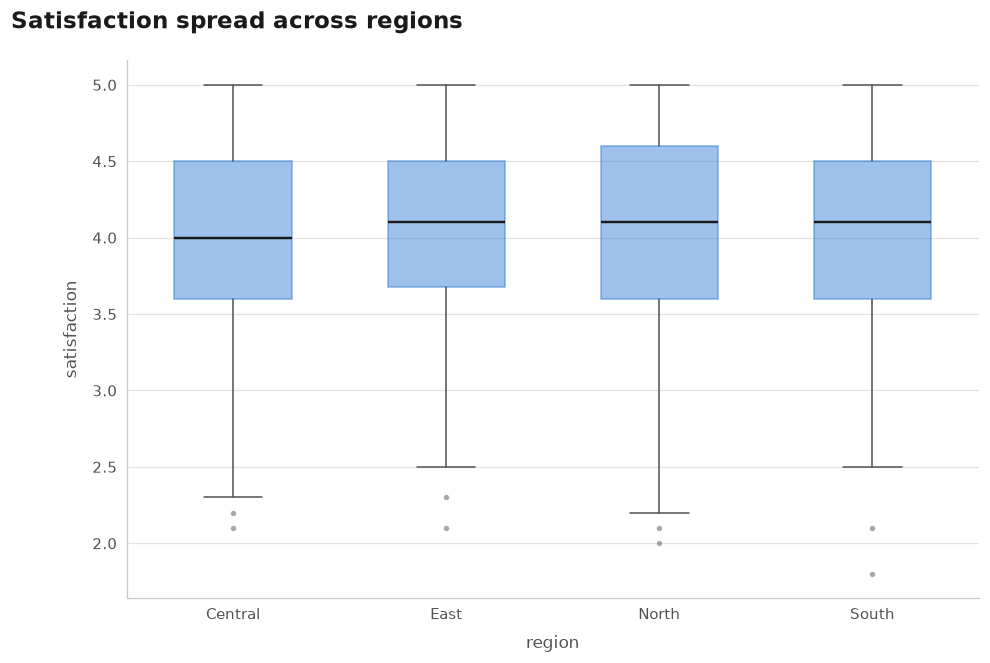

In [10]:
figures[2]

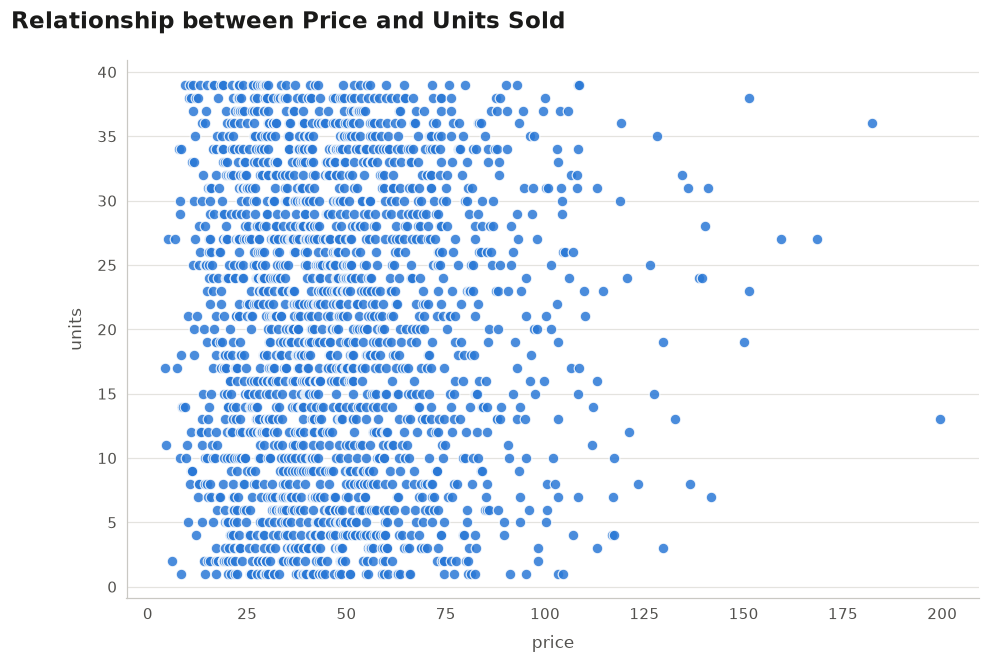

In [11]:
figures[3]

## 7. Follow-up questions

*"same thing, but stacked"* only means something if the model still has the
previous contract in front of it. `message_history` is what puts it there: pass
the messages from the last run into the next one and the model edits its own
answer instead of writing a new one from the question alone.

Two things make this cheap here:

- The contract is small. A turn re-sends a handful of JSON objects, not a
  rendered chart or a table of data.
- `instructions` are **not** stored in the history — Pydantic AI re-applies the
  agent's current ones on every run. Since ours are generated by
  `jp.contract(df)`, a conversation resumed next month is told about the chart
  types that exist next month, not the ones that existed when it started.

Total revenue by region.
  + encoding.x.field = 'region'
  + encoding.x.type = 'nominal'
  + encoding.y.aggregate = 'sum'
  + encoding.y.field = 'revenue'
  + encoding.y.type = 'quantitative'
  + style.title = 'Total revenue by region'
  + viz_type = 'bar'
  [2 messages, 2,608 tokens]


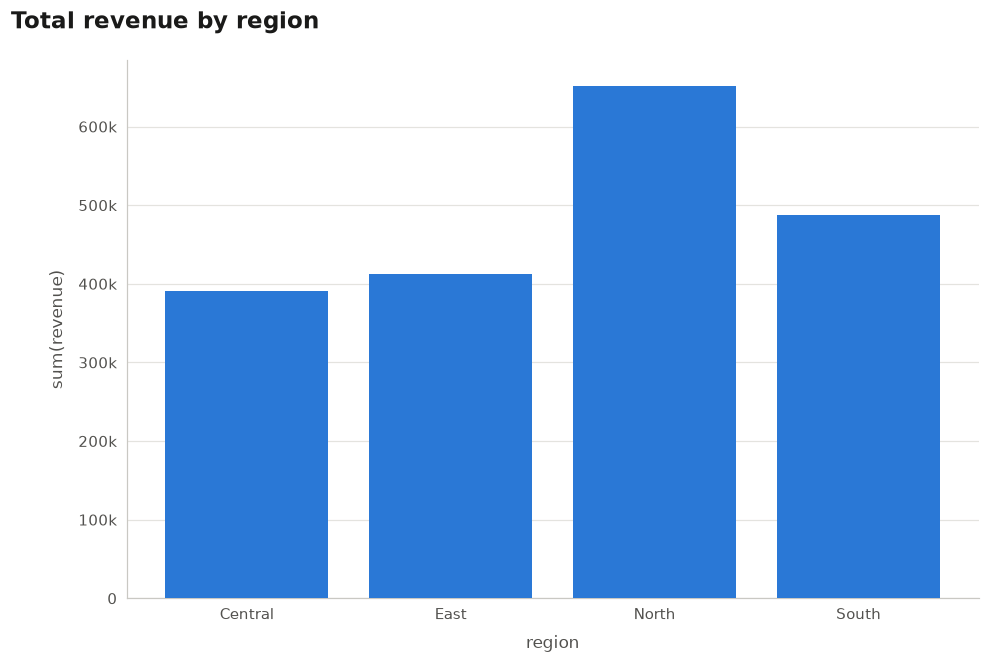

In [12]:
def flatten(node, prefix=""):
    """{'encoding': {'x': {'field': 'region'}}} -> {'encoding.x.field': 'region'}"""
    if not isinstance(node, dict):
        return {prefix: node}
    out = {}
    for key, value in node.items():
        out.update(flatten(value, f"{prefix}.{key}" if prefix else key))
    return out


def changes(before: Spec | None, after: Spec) -> str:
    """What the turn actually did to the contract.

    Worth printing on every turn: the chart shows what changed visually, this
    shows what changed *in the contract*, which is where a follow-up silently
    drops something.
    """
    old = flatten(before.model_dump(exclude_defaults=True)) if before else {}
    new = flatten(after.model_dump(exclude_defaults=True))
    lines = []
    for key in sorted(old | new):
        was, now = old.get(key), new.get(key)
        if was == now:
            continue
        if key not in old:
            lines.append(f"  + {key} = {now!r}")
        elif key not in new:
            lines.append(f"  - {key} dropped (was {was!r})")
        else:
            lines.append(f"  ~ {key}: {was!r} -> {now!r}")
    return "\n".join(lines) or "  (nothing changed)"


class Chat:
    """One conversation about one DataFrame.

    Holds the message history so each turn starts from the last contract, and
    the last contract so each turn can be diffed against it.
    """

    def __init__(self, data: pd.DataFrame):
        self.df = data
        self.messages = []
        self.spec: Spec | None = None

    async def ask(self, question: str):
        result = await chart_agent.run(question, deps=Deps(self.df),
                                       message_history=self.messages)
        self.messages = result.all_messages()      # carried into the next turn
        print(f"{question}\n{changes(self.spec, result.output)}")
        print(f"  [{len(self.messages)} messages, {result.usage.total_tokens:,} tokens]")
        self.spec = result.output
        figure = jp.plot(result.output, self.df)
        plt.close(figure)
        return figure


chat = Chat(df)
await chat.ask("Total revenue by region.")

Same chart, but split by channel.
  + encoding.color.field = 'channel'
  + encoding.color.type = 'nominal'
  ~ style.title: 'Total revenue by region' -> 'Total revenue by region and channel'
  [4 messages, 2,736 tokens]


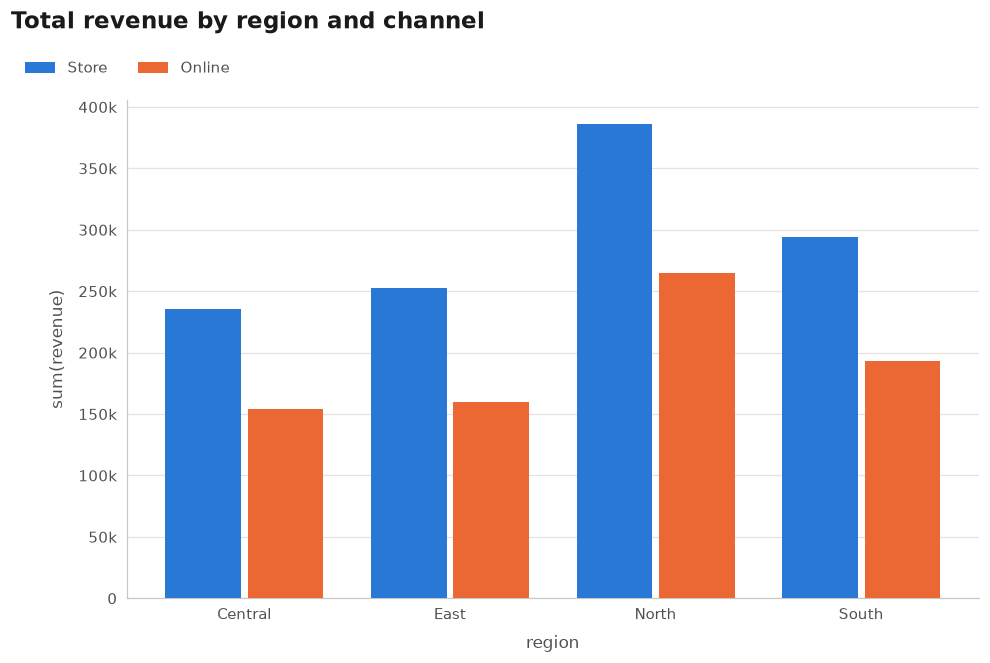

In [13]:
await chat.ask("Same chart, but split by channel.")

Stack it, and make the bars horizontal.
  + style.orientation = 'horizontal'
  [6 messages, 2,872 tokens]


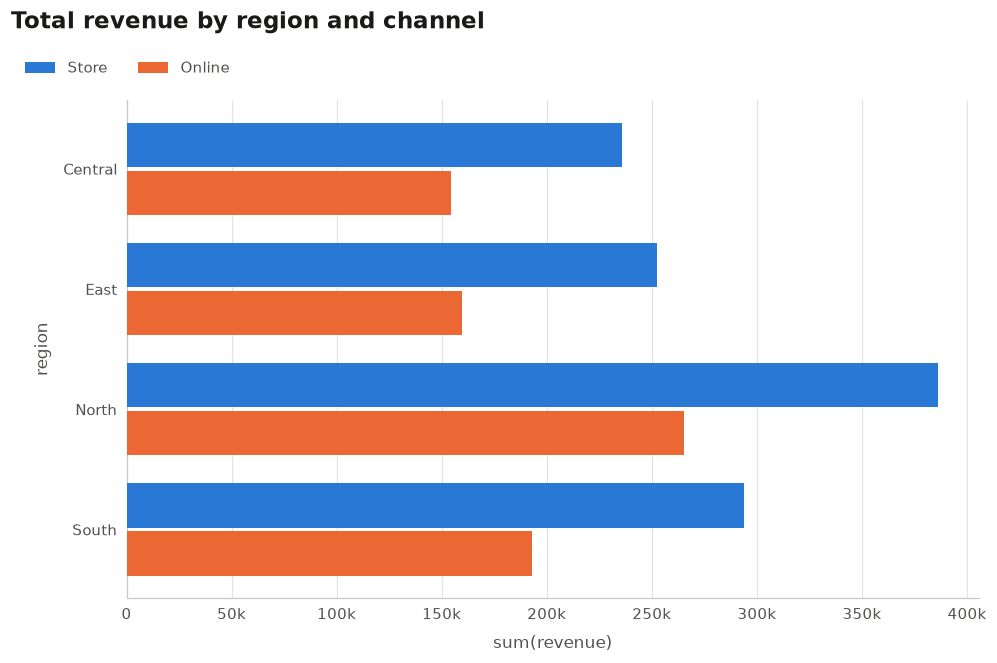

In [14]:
await chat.ask("Stack it, and make the bars horizontal.")

Only North and South, biggest first.
  + data.filters = [{'field': 'region', 'op': 'in', 'value': ['North', 'South']}]
  + data.sort.by = 'y'
  + data.sort.order = 'desc'
  - style.orientation dropped (was 'horizontal')
  ~ style.title: 'Total revenue by region and channel' -> 'Total revenue by region and channel (North and South, biggest first)'
  [8 messages, 3,070 tokens]


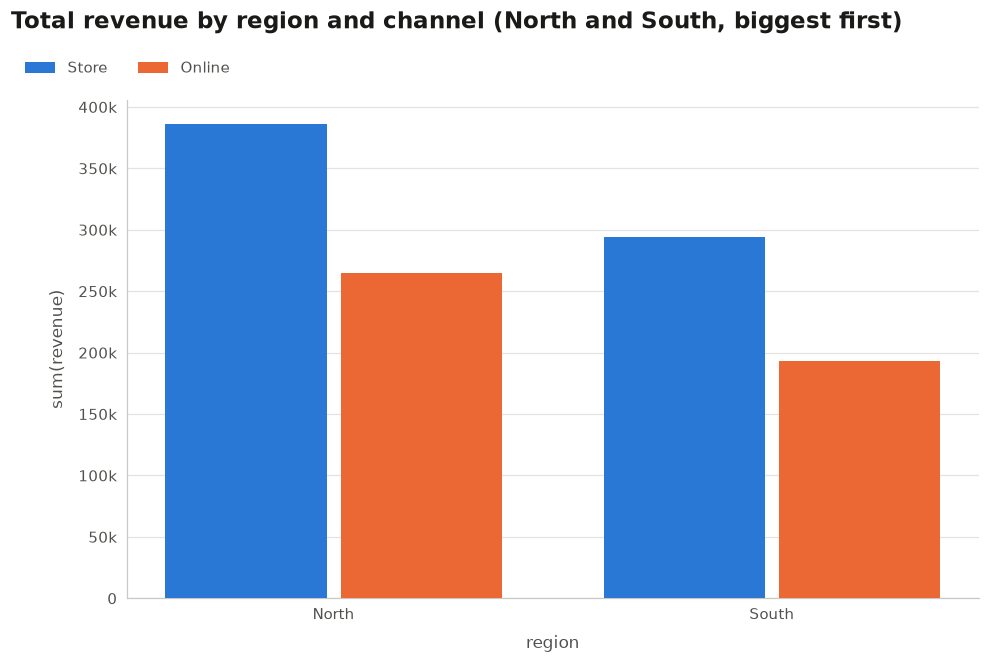

In [15]:
await chat.ask("Only North and South, biggest first.")

### Read the diffs, not just the charts

Two turns above went wrong, and only the diffs say so:

- **"Stack it, and make the bars horizontal"** set `style.orientation` and never
  set `style.stacked`. Half the instruction landed. The chart looks plausible,
  which is exactly what makes it dangerous.
- **"Only North and South, biggest first"** got the filter and the sort right and
  **dropped `style.orientation`** on the way. A follow-up rewrites the whole
  contract, and a 7B model rewriting from memory loses things.

This is the argument for the contract being data rather than code. The drift is
visible, it is addressable, and it is preventable without the model's help —
the previous contract is an object, so edit it:

```python
# both corrections, in Python: no drift possible
fixed = chat.spec.model_copy(update={
    "style": chat.spec.style.model_copy(update={"stacked": True,
                                                "orientation": "horizontal"})
})
jp.plot(fixed, df)
```

Where each approach belongs: let the model handle the turn when the request is
about *what to show* — another dimension, a filter, a different chart type, the
things it got right above. Edit the contract yourself when it is about *how it
looks* and the user is really clicking a toggle. Both write the same object, so
they compose, and `jp.validate` guards either one.

One more thing the history buys: `chat.messages` is serializable
(`ModelMessagesTypeAdapter.dump_json`). A conversation about a chart can be
stored and resumed, and so can the contract it arrived at.

## 8. What this buys, and what to change for production

**Why not just ask for matplotlib code.** A contract is data: it can be
validated before anything is drawn, cached, diffed, stored next to the dashboard
it produced, and shown to the user for editing. Generated code can only be
executed and hoped over.

**Why the contract is generated.** A prompt describing the framework by hand is
stale by the second commit, and a stale prompt is worse than none: it offers a
chart type that no longer exists and hides the one that replaced it. Add a
`viz_type` to `CAPABILITIES` and it appears in `CONTRACT` on the next call —
`jsonplot.spec.briefing.coverage()` and the test suite make sure nothing is left
undocumented.

**Any model, not just this one.** Swap the first argument and the rest of the
notebook is unchanged:

```python
chart_agent = Agent("anthropic:claude-sonnet-5", deps_type=Deps, ...)
```

A 7B model was chosen here precisely because it is unforgiving: `evals/local_llm.py`
measures it at 6/12 correct outcomes without this contract and 11/12 with it,
12/12 with one repair round.

**Worth adding next:**

- Cache on `(question, contract_version)`; the contract is data, so this is an
  ordinary cache.
- Show the user the contract, not just the picture. It is the one part of an
  LLM pipeline a non-programmer can actually correct.
- `jp.tool_definition()` when the chart is one tool among several in a larger
  agent, instead of the whole output type.